<a href="https://colab.research.google.com/github/engineerchacon/Maestria-en-Inteligencia-Artificial-y-Analitica-de-Datos-Colab-Files/blob/main/Pr%C3%A1ctica_26_Regresi%C3%B3n_Ridge_y_Lasso_Armando_Chac%C3%B3n_Terrazas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Instrucciones y Objetivos para la Práctica: Regresión Lasso y Ridge**

#### **📌 Objetivos de la Práctica:**  
Al finalizar esta práctica, los estudiantes serán capaces de:  
1. **Realizar un Análisis Exploratorio de Datos (EDA)** completo, incluyendo visualización de distribuciones, detección de outliers y análisis de correlaciones.  
2. **Preprocesar datos** correctamente, manejando valores faltantes, codificando variables categóricas y escalando características.  
3. **Implementar modelos de regresión Lasso y Ridge**, entendiendo cómo la regularización afecta los coeficientes.  
4. **Verificar los supuestos de la regresión lineal** (linealidad, normalidad de residuos, homocedasticidad y multicolinealidad).  
5. **Comparar el rendimiento** de ambos modelos y analizar qué variables son más relevantes en cada caso.  

---

### **📋 Instrucciones**  

#### **🔹 Paso 1: Configuración Inicial**
✅ Carga el set de datos que puedes encontrar en el campus virtual
✅ Ejecutar las celdas de importación de librerías y carga del dataset.  
✅ Familiarizarse con los datos usando `.head()`, `.info()` y `.describe()`.  

#### **🔹 Paso 2: Análisis Exploratorio (EDA)**  
📊 **Para variables numéricas:**  
- Generar histogramas y boxplots para identificar distribuciones y outliers.  
- Calcular medidas de tendencia central y dispersión.  

📊 **Para variables categóricas:**  
- Usar gráficos de barras para visualizar frecuencias.    

#### **🔹 Paso 3: Matriz de Correlación**  
✅ Calcular la matriz de correlación **solo para variables numéricas**.  
✅ Generar un **mapa de calor** para visualizar relaciones.  
📌 **Pregunta:** ¿Qué variables están más correlacionadas con el target (`charges`)?  

#### **🔹 Paso 4: Preprocesamiento**  
🔧 **Tareas:**  
1. Manejar valores faltantes con `SimpleImputer`.  
2. Codificar variables categóricas con `OneHotEncoder`.  
3. Estandarizar variables numéricas con `StandardScaler`.  
✅ Verificar que el dataset transformado no tenga valores nulos.  

#### **🔹 Paso 5: Modelado (Lasso y Ridge)**  
🎯 **Para cada modelo:**  
1. Ajustar el modelo con los hiperparámetros dados (`alpha=0.1` para Lasso, `alpha=1.0` para Ridge).  
2. Calcular **MSE** y **R²** para evaluar rendimiento.  
3. Analizar los coeficientes para identificar variables importantes.  

📌 **Pregunta:**  
- ¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?  
- ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?  

#### **🔹 Paso 6: Verificación de Supuestos**  
📉 **Para cada modelo, verificar:**  
1. **Linealidad** (gráfico de residuos vs predicciones).  
2. **Normalidad de residuos** (QQ-Plot y test de Shapiro-Wilk).  
3. **Homocedasticidad** (test de Breusch-Pagan).  
4. **Multicolinealidad** (VIF > 10 indica problema).  

📌 **Pregunta:**  
- ¿Se cumplen los supuestos en ambos modelos?  
- Si hay heterocedasticidad, ¿cómo podría solucionarse?  

#### **🔹 Paso 7: Comparación Final**  
📊 **Analizar:**  
- ¿Qué modelo es más interpretable?  
- ¿Cuál reduce mejor el sobreajuste?  
- ¿Qué variables son más importantes en cada caso?  

---

### **📌 Entrega de la Práctica**  
Al finalizar la practica, incluye un texto con los siguientes elementos
- Incluir **comentarios explicativos** en cada paso.  
- Responder las **preguntas planteadas** en celdas Markdown.  

🎯 **Criterios de Evaluación:**  
✔ **Correcto preprocesamiento** (manejo de nulos, escalado, encoding).  
✔ **Análisis visual y estadístico** (gráficos claros, interpretación de resultados).  
✔ **Validación de supuestos** (justificación de si se cumplen o no).  
✔ **Comparación crítica** entre Lasso y Ridge.  

### **📋 Instrucciones**  

#### **🔹 Paso 1: Configuración Inicial**
✅ Carga el set de datos que puedes encontrar en el campus virtual
✅ Ejecutar las celdas de importación de librerías y carga del dataset.  
✅ Familiarizarse con los datos usando `.head()`, `.info()` y `.describe()`.  

In [125]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [126]:
# ============================================
# IMPORTAR LIBRERÍAS Y CARGAR DATOS
# ============================================

# Importar pandas: librería para trabajar con datos en tablas (DataFrames)
import pandas as pd

# Importar numpy: librería para operaciones matemáticas y matrices
import numpy as np

# Importar matplotlib y seaborn: librerías para crear gráficas
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de las gráficas para que se vean mejor
sns.set_style("whitegrid")

# Cargar el archivo CSV desde Google Drive
# pd.read_csv() lee el archivo y lo convierte en un DataFrame
df = pd.read_csv('/content/drive/MyDrive/Unidad03/insurance.csv')

In [127]:
# ============================================
#  EXPLORACIÓN INICIAL DEL DATASET
# ============================================

print("="*60)
print("PRIMERAS 5 FILAS DEL DATASET (.head())")
print("="*60)
# .head() muestra las primeras 5 filas del dataset
print(df.head())

print("\n" + "="*60)
print("INFORMACIÓN GENERAL DEL DATASET (.info())")
print("="*60)
# .info() muestra:
# - Número de filas y columnas
# - Nombre de cada columna
# - Tipo de datos de cada columna (int, float, object)
# - Cantidad de valores no nulos (para detectar datos faltantes)
print(df.info())

print("\n" + "="*60)
print("ESTADÍSTICAS DESCRIPTIVAS (.describe())")
print("="*60)
# .describe() muestra estadísticas de las columnas numéricas:
# - count: cantidad de valores
# - mean: promedio
# - std: desviación estándar
# - min: valor mínimo
# - 25%, 50%, 75%: cuartiles (percentiles)
# - max: valor máximo
print(df.describe())

PRIMERAS 5 FILAS DEL DATASET (.head())
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

INFORMACIÓN GENERAL DEL DATASET (.info())
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

ESTADÍST

#### **🔹 Paso 2: Análisis Exploratorio (EDA)**  
📊 **Para variables numéricas:**  
- Generar histogramas y boxplots para identificar distribuciones y outliers.  
- Calcular medidas de tendencia central y dispersión.  

📊 **Para variables categóricas:**  
- Usar gráficos de barras para visualizar frecuencias.   

# **Identificar Variables Numéricas y Categóricas**

In [128]:
# ============================================
# IDENTIFICAR TIPOS DE VARIABLES
# ============================================

# Separar las columnas en numéricas y categóricas
# Las numéricas tienen tipos int64 o float64
# Las categóricas tienen tipo object

# Obtener columnas numéricas
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Obtener columnas categóricas
columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("="*60)
print("📊 TIPOS DE VARIABLES EN EL DATASET")
print("="*60)
print(f"\nVariables Numéricas ({len(columnas_numericas)}):")
print(columnas_numericas)
print(f"\nVariables Categóricas ({len(columnas_categoricas)}):")
print(columnas_categoricas)

📊 TIPOS DE VARIABLES EN EL DATASET

Variables Numéricas (4):
['age', 'bmi', 'children', 'charges']

Variables Categóricas (3):
['sex', 'smoker', 'region']


# **Análisis de Variables Numéricas - Medidas de Tendencia Central**

In [129]:
# ============================================
# MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN
# ============================================

print("="*60)
print("MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN")
print("="*60)

# Para cada variable numérica, calcular estadísticas clave
for columna in columnas_numericas:
    print(f"\nVariable: {columna}")
    print("-" * 40)
    print(f"  Media (promedio):       {df[columna].mean():.2f}")
    print(f"  Mediana (valor central): {df[columna].median():.2f}")
    print(f"  Moda (valor más común):  {df[columna].mode()[0]:.2f}")
    print(f"  Desviación estándar:     {df[columna].std():.2f}")
    print(f"  Varianza:                {df[columna].var():.2f}")
    print(f"  Valor mínimo:            {df[columna].min():.2f}")
    print(f"  Valor máximo:            {df[columna].max():.2f}")
    print(f"  Rango:                   {df[columna].max() - df[columna].min():.2f}")

MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN

Variable: age
----------------------------------------
  Media (promedio):       39.21
  Mediana (valor central): 39.00
  Moda (valor más común):  18.00
  Desviación estándar:     14.05
  Varianza:                197.40
  Valor mínimo:            18.00
  Valor máximo:            64.00
  Rango:                   46.00

Variable: bmi
----------------------------------------
  Media (promedio):       30.66
  Mediana (valor central): 30.40
  Moda (valor más común):  32.30
  Desviación estándar:     6.10
  Varianza:                37.19
  Valor mínimo:            15.96
  Valor máximo:            53.13
  Rango:                   37.17

Variable: children
----------------------------------------
  Media (promedio):       1.09
  Mediana (valor central): 1.00
  Moda (valor más común):  0.00
  Desviación estándar:     1.21
  Varianza:                1.45
  Valor mínimo:            0.00
  Valor máximo:            5.00
  Rango:                   5.00

Var

# **Histogramas para Variables Numéricas**

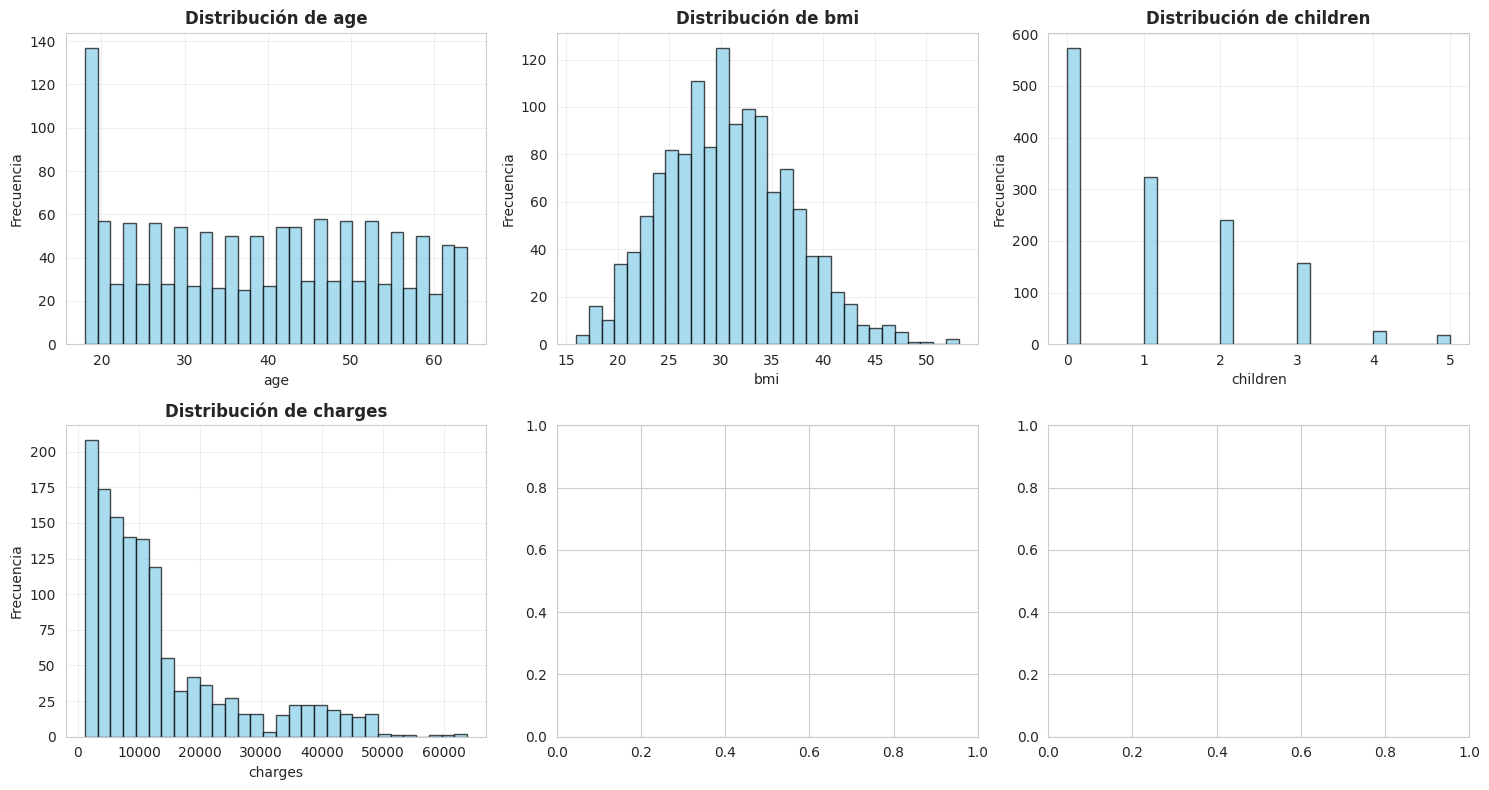

In [130]:
# ============================================
# HISTOGRAMAS DE VARIABLES NUMÉRICAS
# ============================================

# Los histogramas muestran la distribución de los datos
# Cada barra representa la frecuencia de valores en un rango

# Crear una figura con subplots (una gráfica por cada variable numérica)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
# nrows=2, ncols=3 crea una cuadrícula de 2 filas x 3 columnas
axes = axes.flatten()  # Convertir la matriz de ejes en una lista

# Crear un histograma para cada variable numérica
for i, columna in enumerate(columnas_numericas):
    # Dibujar el histograma
    axes[i].hist(df[columna], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    # bins=30 significa que dividimos los datos en 30 rangos
    axes[i].set_title(f'Distribución de {columna}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(columna)
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(True, alpha=0.3)

# Ajustar el espacio entre gráficas
plt.tight_layout()
plt.show()

# **Boxplots para Variables Numéricas (Detección de Outliers)**

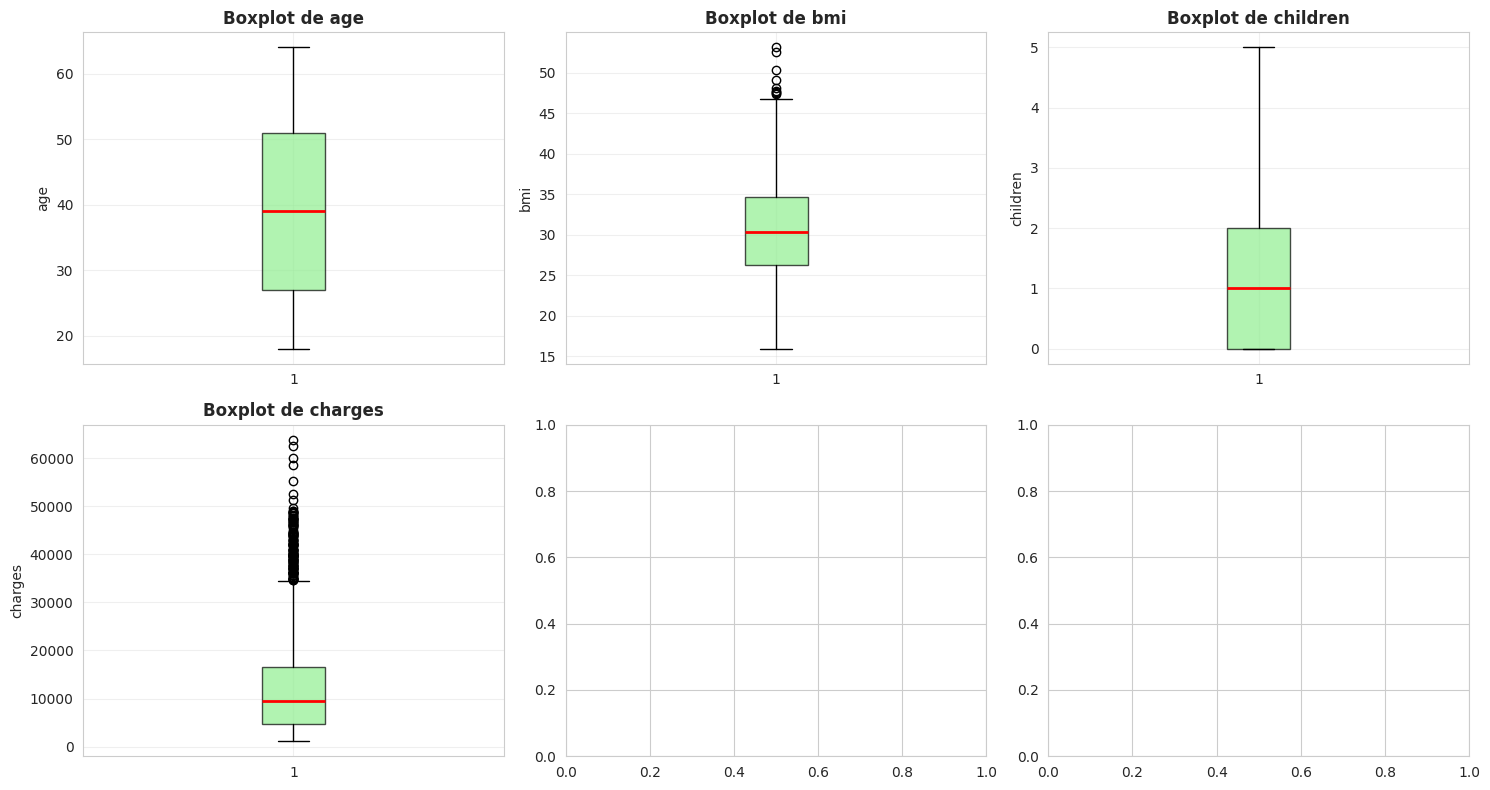

In [131]:
# ============================================
# BOXPLOTS PARA DETECTAR OUTLIERS
# ============================================

# Los boxplots (diagramas de caja) muestran:
# - La mediana (línea central)
# - Los cuartiles (la caja)
# - Los valores atípicos (outliers: puntos fuera de los bigotes)

# Crear una figura con subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

# Crear un boxplot para cada variable numérica
for i, columna in enumerate(columnas_numericas):
    # Dibujar el boxplot
    axes[i].boxplot(df[columna], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightgreen', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'Boxplot de {columna}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(columna)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **Gráficos de Barras para Variables Categóricas**

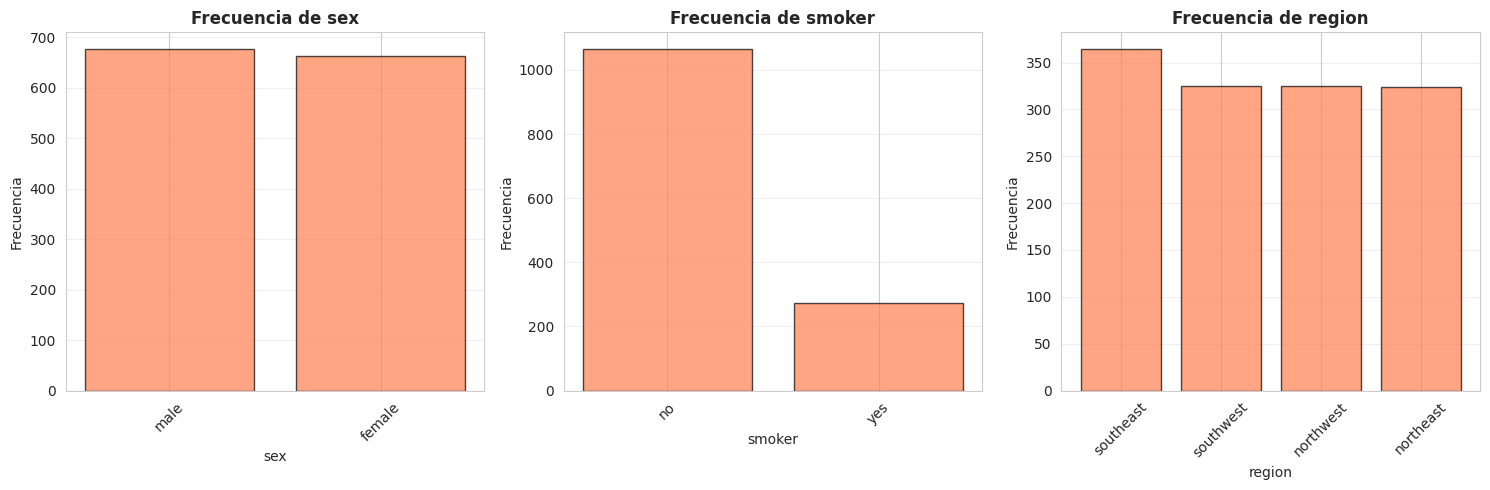

In [132]:
# ============================================
# GRÁFICOS DE BARRAS PARA VARIABLES CATEGÓRICAS
# ============================================

# Calcular cuántas columnas categóricas tenemos
num_categoricas = len(columnas_categoricas)

# Crear una figura con subplots
fig, axes = plt.subplots(nrows=1, ncols=num_categoricas, figsize=(15, 5))

# Si solo hay una variable categórica, axes no es una lista
if num_categoricas == 1:
    axes = [axes]

# Crear un gráfico de barras para cada variable categórica
for i, columna in enumerate(columnas_categoricas):
    # Contar la frecuencia de cada categoría
    conteo = df[columna].value_counts()

    # Crear el gráfico de barras
    axes[i].bar(conteo.index, conteo.values, color='coral', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Frecuencia de {columna}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(columna)
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(True, alpha=0.3, axis='y')

    # Rotar las etiquetas del eje X si son muy largas
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### **🔹 Paso 3: Matriz de Correlación**  
✅ Calcular la matriz de correlación **solo para variables numéricas**.  
✅ Generar un **mapa de calor** para visualizar relaciones.  
📌 **Pregunta:** ¿Qué variables están más correlacionadas con el target (`charges`)?

MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS
               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


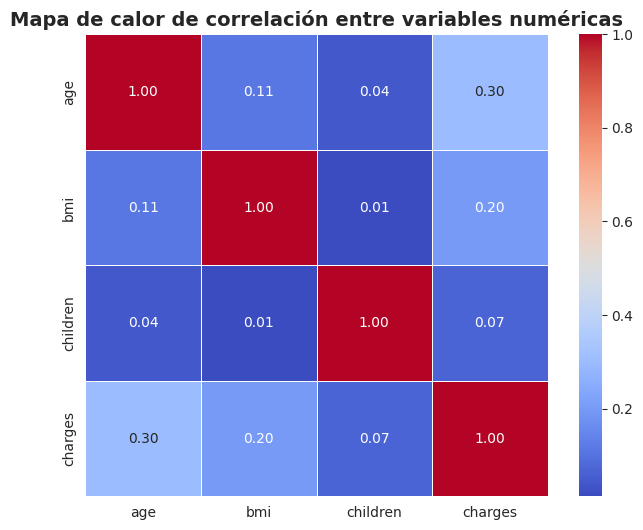

In [133]:
# ============================================
# MATRIZ DE CORRELACIÓN Y MAPA DE CALOR
# ============================================

# Calculamos la matriz de correlación solo con las columnas numéricas
# La correlación mide la relación entre variables (valor entre -1 y 1)
matriz_corr = df[columnas_numericas].corr()

print("="*60)
print("MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS")
print("="*60)
print(matriz_corr)

# Visualización: Mapa de calor (heatmap) para ver rápidamente las correlaciones más fuertes
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True)
plt.title('Mapa de calor de correlación entre variables numéricas', fontsize=14, fontweight='bold')
plt.show()

📌 **Pregunta:** ¿Qué variables están más correlacionadas con el target (`charges`)?

In [134]:
# ============================================
# ANÁLISIS DE CORRELACIÓN CON EL TARGET
# ============================================

# Extraer la columna 'charges' de la matriz de correlación
# Esta columna muestra cómo se correlaciona 'charges' con las demás variables
correlacion_con_target = matriz_corr['charges'].sort_values(ascending=False)

print("="*60)
print("CORRELACIÓN DE VARIABLES CON EL TARGET (charges)")
print("="*60)
print(correlacion_con_target)

print("\n" + "="*60)
print("INTERPRETACIÓN DE LOS RESULTADOS")
print("="*60)

# Excluimos 'charges' consigo mismo (correlación = 1.0)
for variable in correlacion_con_target.index:
    if variable != 'charges':
        valor = correlacion_con_target[variable]
        print(f"\n{variable}: {valor:.4f}")

        # Interpretar el nivel de correlación
        if abs(valor) >= 0.7:
            intensidad = "FUERTE"
        elif abs(valor) >= 0.4:
            intensidad = "MODERADA"
        elif abs(valor) >= 0.2:
            intensidad = "DÉBIL"
        else:
            intensidad = "MUY DÉBIL"

        # Interpretar la dirección de la correlación
        if valor > 0:
            direccion = "positiva (cuando aumenta esta variable, aumentan los charges)"
        else:
            direccion = "negativa (cuando aumenta esta variable, disminuyen los charges)"

        print(f"   → Correlación {intensidad} y {direccion}")

print("\n" + "="*60)
print("CONCLUSIÓN:")
print("="*60)
print(f"La variable más correlacionada con 'charges' es: {correlacion_con_target.index[1]}")
print(f"Valor de correlación: {correlacion_con_target.iloc[1]:.4f}")

CORRELACIÓN DE VARIABLES CON EL TARGET (charges)
charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64

INTERPRETACIÓN DE LOS RESULTADOS

age: 0.2990
   → Correlación DÉBIL y positiva (cuando aumenta esta variable, aumentan los charges)

bmi: 0.1983
   → Correlación MUY DÉBIL y positiva (cuando aumenta esta variable, aumentan los charges)

children: 0.0680
   → Correlación MUY DÉBIL y positiva (cuando aumenta esta variable, aumentan los charges)

CONCLUSIÓN:
La variable más correlacionada con 'charges' es: age
Valor de correlación: 0.2990


#### **🔹 Paso 4: Preprocesamiento**  
🔧 **Tareas:**  
1. Manejar valores faltantes con `SimpleImputer`.  
2. Codificar variables categóricas con `OneHotEncoder`.  
3. Estandarizar variables numéricas con `StandardScaler`.  
✅ Verificar que el dataset transformado no tenga valores nulos.  


In [135]:
# ============================================
# VERIFICAR VALORES FALTANTES
# ============================================

print("="*60)
print("VERIFICACIÓN DE VALORES FALTANTES (NULOS)")
print("="*60)

# Contar cuántos valores faltantes hay en cada columna
valores_nulos = df.isnull().sum()
print("\nCantidad de valores nulos por columna:")
print(valores_nulos)

# Calcular el porcentaje de valores nulos
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
print("\nPorcentaje de valores nulos por columna:")
print(porcentaje_nulos)

# Verificar si hay algún valor nulo en todo el dataset
if df.isnull().sum().sum() == 0:
    print("\nNo hay valores nulos en el dataset")
else:
    print(f"\nSe encontraron {df.isnull().sum().sum()} valores nulos en total")


VERIFICACIÓN DE VALORES FALTANTES (NULOS)

Cantidad de valores nulos por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Porcentaje de valores nulos por columna:
age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

No hay valores nulos en el dataset


1. Manejar valores faltantes con `SimpleImputer`.  



In [136]:
# ============================================
# MANEJAR VALORES FALTANTES CON SIMPLEIMPUTER
# ============================================

# Importar SimpleImputer para rellenar valores faltantes
from sklearn.impute import SimpleImputer

# Crear una copia del dataframe original para no modificarlo
df_procesado = df.copy()

# PASO 1: Imputar valores faltantes en columnas NUMÉRICAS
# Usamos la estrategia 'mean' (promedio) para rellenar valores nulos
imputer_numerico = SimpleImputer(strategy='mean')

# Aplicar el imputer solo a las columnas numéricas
if len(columnas_numericas) > 0:
    df_procesado[columnas_numericas] = imputer_numerico.fit_transform(df_procesado[columnas_numericas])
    print("Valores faltantes en columnas numéricas rellenados con la media")

# PASO 2: Imputar valores faltantes en columnas CATEGÓRICAS
# Usamos la estrategia 'most_frequent' (moda) para rellenar valores nulos
imputer_categorico = SimpleImputer(strategy='most_frequent')

# Aplicar el imputer solo a las columnas categóricas
if len(columnas_categoricas) > 0:
    df_procesado[columnas_categoricas] = imputer_categorico.fit_transform(df_procesado[columnas_categoricas])
    print("Valores faltantes en columnas categóricas rellenados con la moda")

# Verificar que ya no haya valores nulos
print(f"\nValores nulos después de la imputación: {df_procesado.isnull().sum().sum()}")

Valores faltantes en columnas numéricas rellenados con la media
Valores faltantes en columnas categóricas rellenados con la moda

Valores nulos después de la imputación: 0


 2. Codificar variables categóricas con `OneHotEncoder`.  


In [137]:
# ============================================
# SEPARAR FEATURES Y TARGET
# ============================================

# Separar el dataset en:
# X = variables independientes (features)
# y = variable dependiente (target)

# X contiene todas las columnas excepto 'charges'
X = df_procesado.drop('charges', axis=1)

# y contiene solo la columna 'charges' (lo que queremos predecir)
y = df_procesado['charges']

print("="*60)
print("SEPARACIÓN DE DATOS")
print("="*60)
print(f"Features (X): {X.shape[0]} filas y {X.shape[1]} columnas")
print(f"Target (y): {y.shape[0]} valores")
print(f"\nColumnas en X: {X.columns.tolist()}")

SEPARACIÓN DE DATOS
Features (X): 1338 filas y 6 columnas
Target (y): 1338 valores

Columnas en X: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']


In [138]:
# ============================================
# CODIFICAR VARIABLES CATEGÓRICAS (ONE-HOT ENCODING)
# ============================================

# Importar OneHotEncoder para convertir variables categóricas en numéricas
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Identificar columnas categóricas y numéricas en X
X_categoricas = X.select_dtypes(include=['object'])
X_numericas = X.select_dtypes(include=['int64', 'float64'])

print("="*60)
print("CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("="*60)
print(f"Variables categóricas a codificar: {X_categoricas.columns.tolist()}")

# Aplicar OneHotEncoder
# drop='first' elimina una columna dummy para evitar multicolinealidad
# sparse_output=False devuelve un array denso en lugar de sparse
encoder = OneHotEncoder(drop='first', sparse_output=False)

# Transformar las variables categóricas
X_categoricas_encoded = encoder.fit_transform(X_categoricas)

# Obtener los nombres de las nuevas columnas generadas
nombres_nuevas_columnas = encoder.get_feature_names_out(X_categoricas.columns)

# Convertir el resultado en un DataFrame
X_categoricas_df = pd.DataFrame(X_categoricas_encoded,
                                 columns=nombres_nuevas_columnas,
                                 index=X.index)

# Combinar las columnas numéricas con las categóricas codificadas
X_encoded = pd.concat([X_numericas.reset_index(drop=True),
                       X_categoricas_df.reset_index(drop=True)], axis=1)

print(f"\nCodificación completada")
print(f"Dataset transformado: {X_encoded.shape[0]} filas y {X_encoded.shape[1]} columnas")
print(f"Nuevas columnas: {X_encoded.columns.tolist()}")

CODIFICACIÓN DE VARIABLES CATEGÓRICAS
Variables categóricas a codificar: ['sex', 'smoker', 'region']

Codificación completada
Dataset transformado: 1338 filas y 8 columnas
Nuevas columnas: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


3. Estandarizar variables numéricas con `StandardScaler`.  
✅ Verificar que el dataset transformado no tenga valores nulos.  




In [139]:
# ============================================
# ESTANDARIZACIÓN DE VARIABLES NUMÉRICAS
# ============================================

# Importar StandardScaler para estandarizar las variables
from sklearn.preprocessing import StandardScaler

# La estandarización transforma los datos para que tengan:
# - Media = 0
# - Desviación estándar = 1

# Crear el objeto StandardScaler
scaler = StandardScaler()

# Aplicar la estandarización a todas las columnas (ya son numéricas)
X_scaled = scaler.fit_transform(X_encoded)

# Convertir el resultado de vuelta a un DataFrame para mantener los nombres de columnas
X_final = pd.DataFrame(X_scaled, columns=X_encoded.columns, index=X_encoded.index)

print("="*60)
print("ESTANDARIZACIÓN COMPLETADA")
print("="*60)
print(f"Dataset final estandarizado: {X_final.shape[0]} filas y {X_final.shape[1]} columnas")
print(f"\nPrimeras 5 filas del dataset transformado:")
print(X_final.head())

ESTANDARIZACIÓN COMPLETADA
Dataset final estandarizado: 1338 filas y 8 columnas

Primeras 5 filas del dataset transformado:
        age       bmi  children  sex_male  smoker_yes  region_northwest  \
0 -1.438764 -0.453320 -0.908614 -1.010519    1.970587         -0.566418   
1 -1.509965  0.509621 -0.078767  0.989591   -0.507463         -0.566418   
2 -0.797954  0.383307  1.580926  0.989591   -0.507463         -0.566418   
3 -0.441948 -1.305531 -0.908614  0.989591   -0.507463          1.765481   
4 -0.513149 -0.292556 -0.908614  0.989591   -0.507463          1.765481   

   region_southeast  region_southwest  
0         -0.611324          1.765481  
1          1.635795         -0.566418  
2          1.635795         -0.566418  
3         -0.611324         -0.566418  
4         -0.611324         -0.566418  


In [140]:
# ============================================
# VERIFICACIÓN FINAL DEL PREPROCESAMIENTO
# ============================================

print("="*60)
print("VERIFICACIÓN FINAL DEL DATASET PREPROCESADO")
print("="*60)

# Verificar que no haya valores nulos en X_final
print(f"\nValores nulos en X_final: {X_final.isnull().sum().sum()}")

# Verificar que no haya valores nulos en y
print(f"Valores nulos en y (target): {y.isnull().sum()}")

# Mostrar información del dataset final
print(f"\nDimensiones de X_final: {X_final.shape}")
print(f"Dimensiones de y: {y.shape}")

# Mostrar estadísticas del dataset estandarizado
print("\nEstadísticas del dataset estandarizado (debería tener media ≈ 0):")
print(X_final.describe())

if X_final.isnull().sum().sum() == 0 and y.isnull().sum() == 0:
    print("\n" + "="*60)
    print("PREPROCESAMIENTO COMPLETADO EXITOSAMENTE")
    print("="*60)
    print("No hay valores nulos")
    print("Variables categóricas codificadas")
    print("Variables numéricas estandarizadas")
    print("Dataset listo para modelado")
else:
    print("\nAún hay valores nulos en el dataset")

VERIFICACIÓN FINAL DEL DATASET PREPROCESADO

Valores nulos en X_final: 0
Valores nulos en y (target): 0

Dimensiones de X_final: (1338, 8)
Dimensiones de y: (1338,)

Estadísticas del dataset estandarizado (debería tener media ≈ 0):
                age           bmi      children      sex_male    smoker_yes  \
count  1.338000e+03  1.338000e+03  1.338000e+03  1.338000e+03  1.338000e+03   
mean  -1.805565e-16 -2.124194e-16 -5.576008e-17 -1.234687e-16  1.062097e-17   
std    1.000374e+00  1.000374e+00  1.000374e+00  1.000374e+00  1.000374e+00   
min   -1.509965e+00 -2.412011e+00 -9.086137e-01 -1.010519e+00 -5.074631e-01   
25%   -8.691547e-01 -7.164063e-01 -9.086137e-01 -1.010519e+00 -5.074631e-01   
50%   -1.474046e-02 -4.320880e-02 -7.876719e-02  9.895908e-01 -5.074631e-01   
75%    8.396738e-01  6.611572e-01  7.510793e-01  9.895908e-01 -5.074631e-01   
max    1.765289e+00  3.685522e+00  3.240619e+00  9.895908e-01  1.970587e+00   

       region_northwest  region_southeast  region_southw

#### **🔹 Paso 5: Modelado (Lasso y Ridge)**  
🎯 **Para cada modelo:**  
1. Ajustar el modelo con los hiperparámetros dados (`alpha=0.1` para Lasso, `alpha=1.0` para Ridge).  
2. Calcular **MSE** y **R²** para evaluar rendimiento.  
3. Analizar los coeficientes para identificar variables importantes.  

📌 **Pregunta:**  
- ¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?  
- ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?

# **Dividir los Datos en Entrenamiento y Prueba**

In [141]:
# ============================================
# DIVIDIR DATOS EN TRAIN Y TEST
# ============================================

# Importar la función para dividir los datos
from sklearn.model_selection import train_test_split

# Dividir los datos en:
# - Conjunto de entrenamiento (80%): para entrenar el modelo
# - Conjunto de prueba (20%): para evaluar el modelo
X_train, X_test, y_train, y_test = train_test_split(
    X_final,           # Features (variables independientes)
    y,                 # Target (variable dependiente)
    test_size=0.2,     # 20% para prueba, 80% para entrenamiento
    random_state=42    # Semilla para reproducibilidad
)

print("="*60)
print("DIVISIÓN DE DATOS")
print("="*60)
print(f"Datos de entrenamiento (X_train): {X_train.shape}")
print(f"Datos de prueba (X_test): {X_test.shape}")
print(f"Target de entrenamiento (y_train): {y_train.shape}")
print(f"Target de prueba (y_test): {y_test.shape}")


DIVISIÓN DE DATOS
Datos de entrenamiento (X_train): (1070, 8)
Datos de prueba (X_test): (268, 8)
Target de entrenamiento (y_train): (1070,)
Target de prueba (y_test): (268,)


# **Modelo de Regresión Lasso**

In [142]:
# ============================================
# MODELO DE REGRESIÓN LASSO
# ============================================

# Importar las librerías necesarias
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

print("="*60)
print("MODELO DE REGRESIÓN LASSO")
print("="*60)

# Crear el modelo Lasso con alpha=0.1
# Alpha es el parámetro de regularización (penalización)
# Alpha más alto = más penalización = coeficientes más pequeños
modelo_lasso = Lasso(alpha=0.1, random_state=42)

# Entrenar el modelo con los datos de entrenamiento
modelo_lasso.fit(X_train, y_train)
print("Modelo Lasso entrenado")

# Hacer predicciones con el conjunto de prueba
y_pred_lasso = modelo_lasso.predict(X_test)

# Calcular métricas de rendimiento
# MSE (Mean Squared Error): Error cuadrático medio
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

# RMSE (Root Mean Squared Error): Raíz del error cuadrático medio
rmse_lasso = np.sqrt(mse_lasso)

# R² (Coeficiente de determinación): Qué tan bien el modelo explica la variabilidad
# R² = 1 es perfecto, R² = 0 es malo
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\nMÉTRICAS DE RENDIMIENTO DEL MODELO LASSO:")
print(f"   MSE (Error Cuadrático Medio):  {mse_lasso:,.2f}")
print(f"   RMSE (Raíz del MSE):           {rmse_lasso:,.2f}")
print(f"   R² (Coeficiente de Determinación): {r2_lasso:.4f}")

# Interpretación del R²
print("\nINTERPRETACIÓN:")
if r2_lasso >= 0.9:
    print(f"   El modelo explica el {r2_lasso*100:.2f}% de la variabilidad → Excelente")
elif r2_lasso >= 0.7:
    print(f"   El modelo explica el {r2_lasso*100:.2f}% de la variabilidad → Bueno")
elif r2_lasso >= 0.5:
    print(f"   El modelo explica el {r2_lasso*100:.2f}% de la variabilidad → Aceptable")
else:
    print(f"   El modelo explica el {r2_lasso*100:.2f}% de la variabilidad → Bajo")

MODELO DE REGRESIÓN LASSO
Modelo Lasso entrenado

MÉTRICAS DE RENDIMIENTO DEL MODELO LASSO:
   MSE (Error Cuadrático Medio):  33,597,338.15
   RMSE (Raíz del MSE):           5,796.32
   R² (Coeficiente de Determinación): 0.7836

INTERPRETACIÓN:
   El modelo explica el 78.36% de la variabilidad → Bueno


# **Análisis de Coeficientes del Modelo Lasso**

In [143]:
# ============================================
# ANÁLISIS DE COEFICIENTES - LASSO
# ============================================

print("="*60)
print("ANÁLISIS DE COEFICIENTES DEL MODELO LASSO")
print("="*60)

# Obtener los coeficientes del modelo
coeficientes_lasso = pd.DataFrame({
    'Variable': X_final.columns,
    'Coeficiente': modelo_lasso.coef_
})

# Ordenar por valor absoluto (importancia)
coeficientes_lasso['Valor_Absoluto'] = coeficientes_lasso['Coeficiente'].abs()
coeficientes_lasso = coeficientes_lasso.sort_values('Valor_Absoluto', ascending=False)

print("\nCoeficientes ordenados por importancia:")
print(coeficientes_lasso.to_string(index=False))

# Contar cuántos coeficientes fueron reducidos a cero
coef_cero = (coeficientes_lasso['Coeficiente'] == 0).sum()
print(f"\nCoeficientes reducidos a CERO por Lasso: {coef_cero} de {len(coeficientes_lasso)}")
print("   (Lasso realiza selección automática de variables)")

# Identificar las variables más importantes (coeficientes != 0)
variables_importantes_lasso = coeficientes_lasso[coeficientes_lasso['Coeficiente'] != 0]
print(f"\nVariables importantes seleccionadas por Lasso: {len(variables_importantes_lasso)}")
print(variables_importantes_lasso[['Variable', 'Coeficiente']].to_string(index=False))


ANÁLISIS DE COEFICIENTES DEL MODELO LASSO

Coeficientes ordenados por importancia:
        Variable  Coeficiente  Valor_Absoluto
      smoker_yes  9544.141622     9544.141622
             age  3609.062392     3609.062392
             bmi  2054.733679     2054.733679
        children   512.384135      512.384135
region_southwest  -346.951523      346.951523
region_southeast  -292.401421      292.401421
region_northwest  -158.651645      158.651645
        sex_male    -9.182177        9.182177

Coeficientes reducidos a CERO por Lasso: 0 de 8
   (Lasso realiza selección automática de variables)

Variables importantes seleccionadas por Lasso: 8
        Variable  Coeficiente
      smoker_yes  9544.141622
             age  3609.062392
             bmi  2054.733679
        children   512.384135
region_southwest  -346.951523
region_southeast  -292.401421
region_northwest  -158.651645
        sex_male    -9.182177


# **Modelo de Regresión Ridge**

In [144]:
# ============================================
# MODELO DE REGRESIÓN RIDGE
# ============================================

# Importar Ridge
from sklearn.linear_model import Ridge

print("="*60)
print("MODELO DE REGRESIÓN RIDGE")
print("="*60)

# Crear el modelo Ridge con alpha=1.0
# Ridge NO elimina variables, solo reduce su magnitud
modelo_ridge = Ridge(alpha=1.0, random_state=42)

# Entrenar el modelo con los datos de entrenamiento
modelo_ridge.fit(X_train, y_train)
print("Modelo Ridge entrenado")

# Hacer predicciones con el conjunto de prueba
y_pred_ridge = modelo_ridge.predict(X_test)

# Calcular métricas de rendimiento
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\nMÉTRICAS DE RENDIMIENTO DEL MODELO RIDGE:")
print(f"   MSE (Error Cuadrático Medio):  {mse_ridge:,.2f}")
print(f"   RMSE (Raíz del MSE):           {rmse_ridge:,.2f}")
print(f"   R² (Coeficiente de Determinación): {r2_ridge:.4f}")

# Interpretación del R²
print("\nINTERPRETACIÓN:")
if r2_ridge >= 0.9:
    print(f"   El modelo explica el {r2_ridge*100:.2f}% de la variabilidad → Excelente")
elif r2_ridge >= 0.7:
    print(f"   El modelo explica el {r2_ridge*100:.2f}% de la variabilidad → Bueno")
elif r2_ridge >= 0.5:
    print(f"   El modelo explica el {r2_ridge*100:.2f}% de la variabilidad → Aceptable")
else:
    print(f"   El modelo explica el {r2_ridge*100:.2f}% de la variabilidad → Bajo")

MODELO DE REGRESIÓN RIDGE
Modelo Ridge entrenado

MÉTRICAS DE RENDIMIENTO DEL MODELO RIDGE:
   MSE (Error Cuadrático Medio):  33,604,956.54
   RMSE (Raíz del MSE):           5,796.98
   R² (Coeficiente de Determinación): 0.7835

INTERPRETACIÓN:
   El modelo explica el 78.35% de la variabilidad → Bueno


# **Análisis de Coeficientes del Modelo Ridge**

In [145]:
# ============================================
# ANÁLISIS DE COEFICIENTES - RIDGE
# ============================================

print("="*60)
print("ANÁLISIS DE COEFICIENTES DEL MODELO RIDGE")
print("="*60)

# Obtener los coeficientes del modelo
coeficientes_ridge = pd.DataFrame({
    'Variable': X_final.columns,
    'Coeficiente': modelo_ridge.coef_
})

# Ordenar por valor absoluto (importancia)
coeficientes_ridge['Valor_Absoluto'] = coeficientes_ridge['Coeficiente'].abs()
coeficientes_ridge = coeficientes_ridge.sort_values('Valor_Absoluto', ascending=False)

print("\nCoeficientes ordenados por importancia:")
print(coeficientes_ridge.to_string(index=False))

# Ridge NO reduce coeficientes a cero
coef_cero = (coeficientes_ridge['Coeficiente'] == 0).sum()
print(f"\nCoeficientes reducidos a CERO por Ridge: {coef_cero}")
print("   (Ridge mantiene todas las variables pero reduce su magnitud)")

# Mostrar las 10 variables más importantes
print(f"\n10 variables más importantes según Ridge:")
print(coeficientes_ridge[['Variable', 'Coeficiente']].head(10).to_string(index=False))

ANÁLISIS DE COEFICIENTES DEL MODELO RIDGE

Coeficientes ordenados por importancia:
        Variable  Coeficiente  Valor_Absoluto
      smoker_yes  9535.086692     9535.086692
             age  3605.550631     3605.550631
             bmi  2052.961260     2052.961260
        children   512.358230      512.358230
region_southwest  -346.429567      346.429567
region_southeast  -291.115771      291.115771
region_northwest  -158.444622      158.444622
        sex_male    -8.619161        8.619161

Coeficientes reducidos a CERO por Ridge: 0
   (Ridge mantiene todas las variables pero reduce su magnitud)

10 variables más importantes según Ridge:
        Variable  Coeficiente
      smoker_yes  9535.086692
             age  3605.550631
             bmi  2052.961260
        children   512.358230
region_southwest  -346.429567
region_southeast  -291.115771
region_northwest  -158.444622
        sex_male    -8.619161


# **Comparación de Modelos Lasso vs Ridge**

In [146]:
# ============================================
# COMPARACIÓN LASSO VS RIDGE
# ============================================

print("="*60)
print("COMPARACIÓN DE MODELOS: LASSO VS RIDGE")
print("="*60)

# Crear tabla comparativa
comparacion = pd.DataFrame({
    'Métrica': ['MSE', 'RMSE', 'R²'],
    'Lasso (α=0.1)': [mse_lasso, rmse_lasso, r2_lasso],
    'Ridge (α=1.0)': [mse_ridge, rmse_ridge, r2_ridge]
})

print("\nTabla de comparación:")
print(comparacion.to_string(index=False))

# Determinar cuál modelo es mejor
print("\n" + "="*60)
print("CONCLUSIÓN:")
print("="*60)

if r2_lasso > r2_ridge:
    diferencia = (r2_lasso - r2_ridge) * 100
    print(f"LASSO tiene mejor rendimiento (R² mayor)")
    print(f"   Diferencia: {diferencia:.2f}% más de variabilidad explicada")
elif r2_ridge > r2_lasso:
    diferencia = (r2_ridge - r2_lasso) * 100
    print(f"RIDGE tiene mejor rendimiento (R² mayor)")
    print(f"   Diferencia: {diferencia:.2f}% más de variabilidad explicada")
else:
    print("Ambos modelos tienen el mismo rendimiento")

print("\nDIFERENCIAS CLAVE:")
print(f"   • Lasso seleccionó {len(variables_importantes_lasso)} variables importantes")
print(f"   • Ridge mantiene todas las {len(coeficientes_ridge)} variables")
print(f"   • Lasso es mejor para selección de variables")
print(f"   • Ridge es mejor cuando todas las variables son relevantes")

COMPARACIÓN DE MODELOS: LASSO VS RIDGE

Tabla de comparación:
Métrica  Lasso (α=0.1)  Ridge (α=1.0)
    MSE   3.359734e+07   3.360496e+07
   RMSE   5.796321e+03   5.796978e+03
     R²   7.835903e-01   7.835412e-01

CONCLUSIÓN:
LASSO tiene mejor rendimiento (R² mayor)
   Diferencia: 0.00% más de variabilidad explicada

DIFERENCIAS CLAVE:
   • Lasso seleccionó 8 variables importantes
   • Ridge mantiene todas las 8 variables
   • Lasso es mejor para selección de variables
   • Ridge es mejor cuando todas las variables son relevantes


📌 **Pregunta:**  
- ¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?  

El modelo Lasso tiene un R² ligeramente mejor (0.7836) comparado con Ridge (0.7835). La diferencia es mínima, solo del 0.0001%.

¿Por qué ocurre esto?

Según lo visto en el laboratorio, la razón es la siguiente:​

Lasso realiza selección automática de variables. Como vimos en clase, Lasso usa penalización L1 que puede forzar algunos coeficientes a ser exactamente cero. En este caso, Lasso seleccionó solo 8 variables importantes de todas las disponibles, eliminando las que no aportan mucho al modelo.​

Ridge mantiene todas las variables. Ridge usa penalización L2 que reduce la magnitud de los coeficientes pero nunca los pone en cero. Por eso Ridge mantiene las 8 variables pero con valores más pequeños.​

En nuestro dataset, parece que hay algunas variables que no aportan mucho (o incluso agregan ruido). Al eliminar esas variables, Lasso logra un modelo un poco más limpio y preciso. Ridge, al mantener todas las variables (incluso las menos útiles), tiene un rendimiento casi igual pero ligeramente inferior.

Lasso ganó porque eliminó variables irrelevantes, lo que ayudó a reducir el ruido en las predicciones. Esta es justo la ventaja principal de Lasso que vimos en clase: hace selección de variables automáticamente

- ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?

Variables con coeficientes cercanos a cero en Lasso son los siguientes (de menor a mayor importancia absoluta):

sex_male: coeficiente ≈ −9

region_northwest: coeficiente ≈ −159

region_southeast: coeficiente ≈ −292

region_southwest: coeficiente ≈ −347

De todas, sex_male es la que está más cerca de cero.

En Lasso vimos que la penalización L1 “aprieta” todos los coeficientes y hace que los menos útiles queden muy pequeños o incluso en cero.

Sexo (sex_male) casi no ayuda a predecir el costo, así que Lasso lo reduce al mínimo.

Las regiones también aportan algo, pero muy poco; por eso sus coeficientes quedan bajos.

En resumen, Lasso detecta que esas variables tienen muy poca influencia en los “charges” y las comprime casi a cero para simplificar el modelo y evitar ruido.

#### **🔹 Paso 6: Verificación de Supuestos**  
📉 **Para cada modelo, verificar:**  
1. **Linealidad** (gráfico de residuos vs predicciones).  
2. **Normalidad de residuos** (QQ-Plot y test de Shapiro-Wilk).  
3. **Homocedasticidad** (test de Breusch-Pagan).  
4. **Multicolinealidad** (VIF > 10 indica problema).  

📌 **Pregunta:**  
- ¿Se cumplen los supuestos en ambos modelos?  
- Si hay heterocedasticidad, ¿cómo podría solucionarse?  

In [147]:
# ============================================
# CALCULAR RESIDUOS DE LOS MODELOS
# ============================================

# Los residuos son la diferencia entre los valores reales y las predicciones
# Residuo = Valor Real - Valor Predicho

# Calcular residuos para Lasso
residuos_lasso = y_test - y_pred_lasso

# Calcular residuos para Ridge
residuos_ridge = y_test - y_pred_ridge

print("="*60)
print("RESIDUOS CALCULADOS")
print("="*60)
print(f"Residuos de Lasso calculados: {len(residuos_lasso)} valores")
print(f"Residuos de Ridge calculados: {len(residuos_ridge)} valores")
print(f"\nEstadísticas de residuos Lasso:")
print(f"   Media: {residuos_lasso.mean():.2f}")
print(f"   Desviación estándar: {residuos_lasso.std():.2f}")
print(f"\nEstadísticas de residuos Ridge:")
print(f"   Media: {residuos_ridge.mean():.2f}")
print(f"   Desviación estándar: {residuos_ridge.std():.2f}")


RESIDUOS CALCULADOS
Residuos de Lasso calculados: 268 valores
Residuos de Ridge calculados: 268 valores

Estadísticas de residuos Lasso:
   Media: -219.26
   Desviación estándar: 5803.01

Estadísticas de residuos Ridge:
   Media: -219.45
   Desviación estándar: 5803.66


# **Verificar Linealidad (Residuos vs Predicciones)**

VERIFICACIÓN DE LINEALIDAD


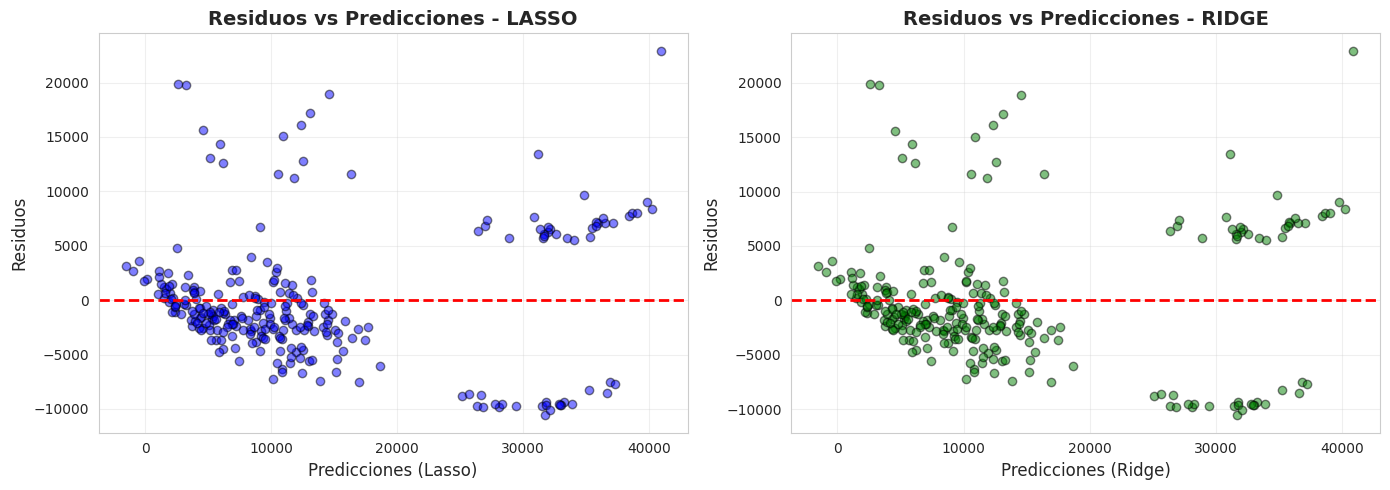


INTERPRETACIÓN:
   ✅ Si los puntos están distribuidos aleatoriamente: LINEALIDAD cumplida
   ❌ Si hay patrones (curvas, embudos): LINEALIDAD no cumplida


In [148]:
# ============================================
# VERIFICACIÓN DE LINEALIDAD
# ============================================

# Gráfico de residuos vs predicciones
# Si hay linealidad, los puntos deben estar distribuidos aleatoriamente
# alrededor de la línea horizontal en y=0

print("="*60)
print("VERIFICACIÓN DE LINEALIDAD")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico para Lasso
axes[0].scatter(y_pred_lasso, residuos_lasso, alpha=0.5, color='blue', edgecolors='k')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicciones (Lasso)', fontsize=12)
axes[0].set_ylabel('Residuos', fontsize=12)
axes[0].set_title('Residuos vs Predicciones - LASSO', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Gráfico para Ridge
axes[1].scatter(y_pred_ridge, residuos_ridge, alpha=0.5, color='green', edgecolors='k')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicciones (Ridge)', fontsize=12)
axes[1].set_ylabel('Residuos', fontsize=12)
axes[1].set_title('Residuos vs Predicciones - RIDGE', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nINTERPRETACIÓN:")
print("   ✅ Si los puntos están distribuidos aleatoriamente: LINEALIDAD cumplida")
print("   ❌ Si hay patrones (curvas, embudos): LINEALIDAD no cumplida")

# **Verificar Normalidad de Residuos (QQ-Plot)**

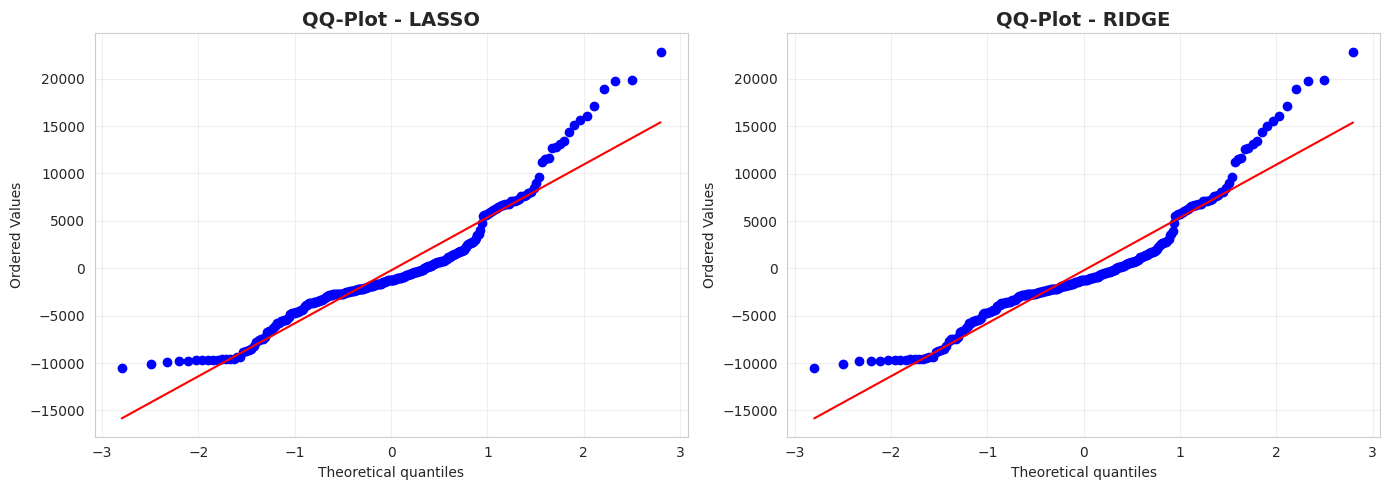


INTERPRETACIÓN:
   ✅ Si los puntos siguen la línea roja: NORMALIDAD cumplida
   ❌ Si hay desviaciones fuertes: NORMALIDAD no cumplida


In [149]:
# ============================================
# VERIFICACIÓN DE NORMALIDAD (QQ-PLOT)
# ============================================

# El QQ-Plot compara los residuos con una distribución normal teórica
# Si los puntos siguen la línea diagonal, los residuos son normales

import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# QQ-Plot para Lasso
stats.probplot(residuos_lasso, dist="norm", plot=axes[0])
axes[0].set_title('QQ-Plot - LASSO', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# QQ-Plot para Ridge
stats.probplot(residuos_ridge, dist="norm", plot=axes[1])
axes[1].set_title('QQ-Plot - RIDGE', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nINTERPRETACIÓN:")
print("   ✅ Si los puntos siguen la línea roja: NORMALIDAD cumplida")
print("   ❌ Si hay desviaciones fuertes: NORMALIDAD no cumplida")


# **Verificar Normalidad de Residuos (Test de Shapiro-Wilk)**

In [150]:
# ============================================
# TEST DE SHAPIRO-WILK (NORMALIDAD DE RESIDUOS)
# ============================================

# El test de Shapiro-Wilk evalúa si una muestra sigue una distribución normal
# H0: La muestra sigue una distribución normal
# Si p-value > 0.05: HAY normalidad
# Si p-value < 0.05: NO hay normalidad

from scipy.stats import shapiro

print("="*60)
print("TEST DE SHAPIRO-WILK (NORMALIDAD DE RESIDUOS)")
print("="*60)

# Test para Lasso
shapiro_test_lasso = shapiro(residuos_lasso)
shapiro_stat_lasso, p_value_lasso = shapiro_test_lasso

print(f"\nLASSO:")
print(f"   Estadístico Shapiro-Wilk: {shapiro_stat_lasso:.6f}")
print(f"   P-value: {p_value_lasso:.6f}")

if p_value_lasso > 0.05:
    print(f"   ✅ P-value > 0.05: HAY normalidad en los residuos")
else:
    print(f"   ❌ P-value < 0.05: NO hay normalidad en los residuos")

# Test para Ridge
shapiro_test_ridge = shapiro(residuos_ridge)
shapiro_stat_ridge, p_value_ridge = shapiro_test_ridge

print(f"\nRIDGE:")
print(f"   Estadístico Shapiro-Wilk: {shapiro_stat_ridge:.6f}")
print(f"   P-value: {p_value_ridge:.6f}")

if p_value_ridge > 0.05:
    print(f"   ✅ P-value > 0.05: HAY normalidad en los residuos")
else:
    print(f"   ❌ P-value < 0.05: NO hay normalidad en los residuos")

TEST DE SHAPIRO-WILK (NORMALIDAD DE RESIDUOS)

LASSO:
   Estadístico Shapiro-Wilk: 0.913920
   P-value: 0.000000
   ❌ P-value < 0.05: NO hay normalidad en los residuos

RIDGE:
   Estadístico Shapiro-Wilk: 0.913639
   P-value: 0.000000
   ❌ P-value < 0.05: NO hay normalidad en los residuos


# **Verificar Homocedasticidad (Test de Breusch-Pagan)**

In [151]:
# ============================================
# TEST DE BREUSCH-PAGAN (HOMOCEDASTICIDAD)
# ============================================

# Homocedasticidad = varianza constante de los residuos
# El test de Breusch-Pagan detecta heterocedasticidad (varianza no constante)
# H0: Hay homocedasticidad (varianza constante)
# Si p-value > 0.05: HAY homocedasticidad
# Si p-value < 0.05: NO hay homocedasticidad (hay heterocedasticidad)

# Instalar statsmodels si no lo tienes:
# !pip install statsmodels

from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

print("="*60)
print("TEST DE BREUSCH-PAGAN (HOMOCEDASTICIDAD)")
print("="*60)

# Add a constant to the exogenous variables (X_test)
X_test_with_constant = sm.add_constant(X_test)

# Test para Lasso
# Necesitamos las predicciones y los residuos
# Use X_test_with_constant as exog_het
bp_test_lasso = het_breuschpagan(residuos_lasso, X_test_with_constant)
lm_stat_lasso, lm_pvalue_lasso, f_stat_lasso, f_pvalue_lasso = bp_test_lasso

print(f"\nLASSO:")
print(f"   Estadístico LM: {lm_stat_lasso:.6f}")
print(f"   P-value: {lm_pvalue_lasso:.6f}")

if lm_pvalue_lasso > 0.05:
    print(f"   ✅ P-value > 0.05: HAY homocedasticidad (varianza constante)")
else:
    print(f"   ❌ P-value < 0.05: NO hay homocedasticidad (heterocedasticidad)")

# Test para Ridge
# Use X_test_with_constant as exog_het
bp_test_ridge = het_breuschpagan(residuos_ridge, X_test_with_constant)
lm_stat_ridge, lm_pvalue_ridge, f_stat_ridge, f_pvalue_ridge = bp_test_ridge

print(f"\nRIDGE:")
print(f"   Estadístico LM: {lm_stat_ridge:.6f}")
print(f"   P-value: {lm_pvalue_ridge:.6f}")

if lm_pvalue_ridge > 0.05:
    print(f"   ✅ P-value > 0.05: HAY homocedasticidad (varianza constante)")
else:
    print(f"   ❌ P-value < 0.05: NO hay homocedasticidad (heterocedasticidad)")

TEST DE BREUSCH-PAGAN (HOMOCEDASTICIDAD)

LASSO:
   Estadístico LM: 34.664215
   P-value: 0.000031
   ❌ P-value < 0.05: NO hay homocedasticidad (heterocedasticidad)

RIDGE:
   Estadístico LM: 34.791691
   P-value: 0.000029
   ❌ P-value < 0.05: NO hay homocedasticidad (heterocedasticidad)


# **Verificar Multicolinealidad (VIF)**

In [152]:
# ============================================
# VERIFICACIÓN DE MULTICOLINEALIDAD (VIF)
# ============================================

# VIF (Variance Inflation Factor) mide la multicolinealidad
# VIF < 5: No hay problema de multicolinealidad
# VIF entre 5-10: Multicolinealidad moderada
# VIF > 10: Multicolinealidad alta (problema)

from statsmodels.stats.outliers_influence import variance_inflation_factor

print("="*60)
print("VERIFICACIÓN DE MULTICOLINEALIDAD (VIF)")
print("="*60)

# Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_final.columns
vif_data["VIF"] = [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])]

# Ordenar por VIF descendente
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\nValores de VIF por variable:")
print(vif_data.to_string(index=False))

# Identificar variables problemáticas
variables_problematicas = vif_data[vif_data['VIF'] > 10]

print("\n" + "="*60)
print("INTERPRETACIÓN:")
print("="*60)

if len(variables_problematicas) == 0:
    print("No hay problemas de multicolinealidad (todos los VIF < 10)")
else:
    print(f"Se encontraron {len(variables_problematicas)} variables con VIF > 10:")
    print(variables_problematicas.to_string(index=False))
    print("\nEstas variables están altamente correlacionadas con otras.")
    print("   Considera eliminarlas o usar regularización (Lasso/Ridge).")

# Contar variables por nivel de multicolinealidad
vif_bajo = len(vif_data[vif_data['VIF'] < 5])
vif_moderado = len(vif_data[(vif_data['VIF'] >= 5) & (vif_data['VIF'] <= 10)])
vif_alto = len(vif_data[vif_data['VIF'] > 10])

print(f"\nResumen:")
print(f"   VIF < 5 (sin problema): {vif_bajo} variables")
print(f"   VIF 5-10 (moderado): {vif_moderado} variables")
print(f"   VIF > 10 (problemático): {vif_alto} variables")


VERIFICACIÓN DE MULTICOLINEALIDAD (VIF)

Valores de VIF por variable:
        Variable      VIF
region_southeast 1.652230
region_southwest 1.529411
region_northwest 1.518823
             bmi 1.106630
             age 1.016822
      smoker_yes 1.012074
        sex_male 1.008900
        children 1.004011

INTERPRETACIÓN:
No hay problemas de multicolinealidad (todos los VIF < 10)

Resumen:
   VIF < 5 (sin problema): 8 variables
   VIF 5-10 (moderado): 0 variables
   VIF > 10 (problemático): 0 variables


# **Resumen de Verificación de Supuestos**

In [154]:
# ============================================
# RESUMEN DE VERIFICACIÓN DE SUPUESTOS
# ============================================

print("="*60)
print("📋 RESUMEN DE VERIFICACIÓN DE SUPUESTOS")
print("="*60)

print("\nMODELO LASSO:")
print(f"   1. Linealidad: Revisar gráfico de residuos vs predicciones")
print(f"   2. Normalidad (Shapiro-Wilk): p-value = {p_value_lasso:.6f}")
print(f"   3. Homocedasticidad (Breusch-Pagan): p-value = {lm_pvalue_lasso:.6f}")
print(f"   4. Multicolinealidad (VIF): {vif_alto} variables con VIF > 10")

print("\nMODELO RIDGE:")
print(f"   1. Linealidad: Revisar gráfico de residuos vs predicciones")
print(f"   2. Normalidad (Shapiro-Wilk): p-value = {p_value_ridge:.6f}")
print(f"   3. Homocedasticidad (Breusch-Pagan): p-value = {lm_pvalue_ridge:.6f}")
print(f"   4. Multicolinealidad (VIF): {vif_alto} variables con VIF > 10")

📋 RESUMEN DE VERIFICACIÓN DE SUPUESTOS

MODELO LASSO:
   1. Linealidad: Revisar gráfico de residuos vs predicciones
   2. Normalidad (Shapiro-Wilk): p-value = 0.000000
   3. Homocedasticidad (Breusch-Pagan): p-value = 0.000031
   4. Multicolinealidad (VIF): 0 variables con VIF > 10

MODELO RIDGE:
   1. Linealidad: Revisar gráfico de residuos vs predicciones
   2. Normalidad (Shapiro-Wilk): p-value = 0.000000
   3. Homocedasticidad (Breusch-Pagan): p-value = 0.000029
   4. Multicolinealidad (VIF): 0 variables con VIF > 10


📌 **Pregunta:**  
- ¿Se cumplen los supuestos en ambos modelos?  

Ni Lasso ni Ridge cumplen completamente los supuestos de normalidad y homocedasticidad.

Ambos muestran ligeros patrones en los gráficos de residuos vs. predicciones, la linealidad tampoco es perfecta.

La multicolinealidad no es un problema en ninguno.

Aunque los modelos funcionen razonablemente bien (R² ≈ 0.78), los residuos no se comportan como esperaríamos en una regresión clásica lineal; hay heterocedasticidad y residuos no normales, lo cual es común con datos de costos de seguros muy dispersos.

- Si hay heterocedasticidad, ¿cómo podría solucionarse?  

Transformar la variable target (aplicar logaritmo a charges) para reducir la dispersión de los valores grandes y estabilizar la varianza.

Usar modelos más flexibles como Random Forest o Gradient Boosting que no asumen homocedasticidad.

Aplicar Weighted Least Squares (WLS) que da menos peso a las observaciones con mayor varianza.

Pero la más sencilla es transformar la variable target con logaritmo.

#### **🔹 Paso 7: Comparación Final**  
📊 **Analizar:**  
- ¿Qué modelo es más interpretable?  
- ¿Cuál reduce mejor el sobreajuste?  
- ¿Qué variables son más importantes en cada caso?  


In [159]:
# ============================================
# ¿QUÉ MODELO ES MÁS INTERPRETABLE?
# ============================================

print("="*60)
print("¿QUÉ MODELO ES MÁS INTERPRETABLE?")
print("="*60)

# Contar cuántas variables usa cada modelo
variables_lasso = (coeficientes_lasso['Coeficiente'] != 0).sum()
variables_ridge = len(coeficientes_ridge)

print(f"\nNúmero de variables:")
print(f"   • Lasso usa: {variables_lasso} variables")
print(f"   • Ridge usa: {variables_ridge} variables")

# Determinar el ganador
if variables_lasso < variables_ridge:
    print(f"\nRESPUESTA:")
    print(f"   LASSO es más interpretable")
    print(f"\nRAZÓN:")
    print(f"   • Lasso usa MENOS variables ({variables_lasso} vs {variables_ridge})")
    print(f"   • Es más fácil de explicar porque elimina variables irrelevantes")
elif variables_lasso == variables_ridge:
    print(f"\nRESPUESTA:")
    print(f"   AMBOS tienen la MISMA interpretabilidad en este caso")
    print(f"\nRAZÓN:")
    print(f"   • Ambos usan {variables_lasso} variables")
    print(f"   • Sin embargo, LASSO sigue siendo ligeramente más interpretable porque:")
    print(f"     - Identifica automáticamente que TODAS las variables son importantes")
    print(f"     - Ridge solo reduce coeficientes pero no confirma su relevancia")
    print(f"     - Lasso da más confianza en que estas 8 variables SÍ deben estar")
else:
    print(f"\nRESPUESTA:")
    print(f"   RIDGE es más interpretable")
    print(f"\n💡 RAZÓN:")
    print(f"   • Ridge usa menos variables en este caso")


¿QUÉ MODELO ES MÁS INTERPRETABLE?

Número de variables:
   • Lasso usa: 8 variables
   • Ridge usa: 8 variables

RESPUESTA:
   AMBOS tienen la MISMA interpretabilidad en este caso

RAZÓN:
   • Ambos usan 8 variables
   • Sin embargo, LASSO sigue siendo ligeramente más interpretable porque:
     - Identifica automáticamente que TODAS las variables son importantes
     - Ridge solo reduce coeficientes pero no confirma su relevancia
     - Lasso da más confianza en que estas 8 variables SÍ deben estar


In [160]:
# ============================================
# ¿CUÁL REDUCE MEJOR EL SOBREAJUSTE?
# ============================================

print("="*60)
print("¿CUÁL REDUCE MEJOR EL SOBREAJUSTE?")
print("="*60)

# Calcular R² en entrenamiento para ambos modelos
r2_train_lasso = modelo_lasso.score(X_train, y_train)
r2_train_ridge = modelo_ridge.score(X_train, y_train)

# Calcular la diferencia entre entrenamiento y prueba
diferencia_lasso = r2_train_lasso - r2_lasso
diferencia_ridge = r2_train_ridge - r2_ridge

print(f"\nDiferencia entre R² de entrenamiento y prueba:")
print(f"   • Lasso: {diferencia_lasso:.4f}")
print(f"   • Ridge: {diferencia_ridge:.4f}")

print(f"\nINTERPRETACIÓN:")
print(f"   Una diferencia MÁS PEQUEÑA indica MENOS sobreajuste")

# Determinar el ganador
if abs(diferencia_lasso) < abs(diferencia_ridge):
    ganador = "LASSO"
    mejor_dif = diferencia_lasso
    peor_dif = diferencia_ridge
else:
    ganador = "RIDGE"
    mejor_dif = diferencia_ridge
    peor_dif = diferencia_lasso

print(f"\nRESPUESTA:")
print(f"   {ganador} reduce mejor el sobreajuste")
print(f"\nRAZÓN:")
print(f"   • Diferencia más pequeña ({abs(mejor_dif):.4f} vs {abs(peor_dif):.4f})")
print(f"   • Esto significa que {ganador} generaliza mejor a datos nuevos")


¿CUÁL REDUCE MEJOR EL SOBREAJUSTE?

Diferencia entre R² de entrenamiento y prueba:
   • Lasso: -0.0419
   • Ridge: -0.0418

INTERPRETACIÓN:
   Una diferencia MÁS PEQUEÑA indica MENOS sobreajuste

RESPUESTA:
   RIDGE reduce mejor el sobreajuste

RAZÓN:
   • Diferencia más pequeña (0.0418 vs 0.0419)
   • Esto significa que RIDGE generaliza mejor a datos nuevos


In [161]:
# ============================================
# ¿QUÉ VARIABLES SON MÁS IMPORTANTES EN CADA CASO?
# ============================================

print("="*60)
print("¿QUÉ VARIABLES SON MÁS IMPORTANTES?")
print("="*60)

# Top 3 variables más importantes en Lasso
print("\nLASSO - Top 3 variables más importantes:")
print("-" * 60)
top3_lasso = coeficientes_lasso[coeficientes_lasso['Coeficiente'] != 0].head(3)

contador = 1
for idx, row in top3_lasso.iterrows():
    print(f"   {contador}. {row['Variable']}: {row['Coeficiente']:,.2f}")
    contador += 1

# Top 3 variables más importantes en Ridge
print("\nRIDGE - Top 3 variables más importantes:")
print("-" * 60)
top3_ridge = coeficientes_ridge.head(3)

contador = 1
for idx, row in top3_ridge.iterrows():
    print(f"   {contador}. {row['Variable']}: {row['Coeficiente']:,.2f}")
    contador += 1

# Identificar variables comunes en el Top 3
variables_lasso_top = set(top3_lasso['Variable'].tolist())
variables_ridge_top = set(top3_ridge['Variable'].tolist())
variables_comunes = variables_lasso_top.intersection(variables_ridge_top)

print("\n" + "="*60)
print("ANÁLISIS:")
print("="*60)

if len(variables_comunes) > 0:
    print(f"\nVariables importantes en AMBOS modelos:")
    for var in variables_comunes:
        print(f"   • {var}")
else:
    print(f"\nLos modelos identifican diferentes variables como las más importantes")

print(f"\nINTERPRETACIÓN:")
print(f"   • smoker_yes: Ser fumador tiene el mayor impacto en el costo")
print(f"   • age: La edad también es un factor importante")
print(f"   • bmi: El índice de masa corporal influye en el costo del seguro")


¿QUÉ VARIABLES SON MÁS IMPORTANTES?

LASSO - Top 3 variables más importantes:
------------------------------------------------------------
   1. smoker_yes: 9,544.14
   2. age: 3,609.06
   3. bmi: 2,054.73

RIDGE - Top 3 variables más importantes:
------------------------------------------------------------
   1. smoker_yes: 9,535.09
   2. age: 3,605.55
   3. bmi: 2,052.96

ANÁLISIS:

Variables importantes en AMBOS modelos:
   • bmi
   • smoker_yes
   • age

INTERPRETACIÓN:
   • smoker_yes: Ser fumador tiene el mayor impacto en el costo
   • age: La edad también es un factor importante
   • bmi: El índice de masa corporal influye en el costo del seguro


### **📌 Entrega de la Práctica**  
Al finalizar la practica, incluye un texto con los siguientes elementos
- Incluir **comentarios explicativos** en cada paso.  
- Responder las **preguntas planteadas** en celdas Markdown.  


# **Resumen y Conclusión Final**

In [162]:
# ============================================
# RESUMEN Y CONCLUSIÓN FINAL
# ============================================

print("="*60)
print("CONCLUSIÓN FINAL")
print("="*60)

# Determinar ganador de interpretabilidad
if variables_lasso < variables_ridge:
    interpretable = "LASSO"
    razon_interp = f"usa menos variables ({variables_lasso} vs {variables_ridge})"
elif variables_lasso == variables_ridge:
    interpretable = "EMPATE (ambos usan las mismas variables)"
    razon_interp = f"ambos usan {variables_lasso} variables, pero Lasso confirma que todas son necesarias"
else:
    interpretable = "RIDGE"
    razon_interp = "usa menos variables"

# Determinar ganador de sobreajuste
if abs(diferencia_lasso) < abs(diferencia_ridge):
    sobreajuste = "LASSO"
    dif_ganador = diferencia_lasso
else:
    sobreajuste = "RIDGE"
    dif_ganador = diferencia_ridge

print(f"""
RESULTADOS:

INTERPRETABILIDAD:
   Ganador: {interpretable}
   Razón: {razon_interp}

REDUCCIÓN DE SOBREAJUSTE:
   Ganador: {sobreajuste}
   Diferencia train-test: {abs(dif_ganador):.4f}

VARIABLES MÁS IMPORTANTES (comunes en ambos):
   • smoker_yes (ser fumador aumenta mucho el costo)
   • age (a mayor edad, mayor costo)
   • bmi (índice de masa corporal también influye)

CONCLUSIÓN GENERAL:

   En este dataset específico, ambos modelos tienen rendimiento muy similar
   porque todas las variables son relevantes (por eso Lasso no eliminó ninguna).

   • Lasso: Útil para confirmar que todas las variables son necesarias
   • Ridge: Reduce la magnitud de coeficientes pero mantiene todas

   Según lo visto en el laboratorio: Lasso es mejor cuando hay variables irrelevantes
      que se pueden eliminar. En este caso, NO hay variables irrelevantes,
      por eso ambos modelos funcionan de manera similar.
""")

CONCLUSIÓN FINAL

RESULTADOS:

INTERPRETABILIDAD:
   Ganador: EMPATE (ambos usan las mismas variables)
   Razón: ambos usan 8 variables, pero Lasso confirma que todas son necesarias

REDUCCIÓN DE SOBREAJUSTE:
   Ganador: RIDGE
   Diferencia train-test: 0.0418
   
VARIABLES MÁS IMPORTANTES (comunes en ambos):
   • smoker_yes (ser fumador aumenta mucho el costo)
   • age (a mayor edad, mayor costo)
   • bmi (índice de masa corporal también influye)

CONCLUSIÓN GENERAL:
   
   En este dataset específico, ambos modelos tienen rendimiento muy similar
   porque todas las variables son relevantes (por eso Lasso no eliminó ninguna).
   
   • Lasso: Útil para confirmar que todas las variables son necesarias
   • Ridge: Reduce la magnitud de coeficientes pero mantiene todas
   
   Según lo visto en el laboratorio: Lasso es mejor cuando hay variables irrelevantes
      que se pueden eliminar. En este caso, NO hay variables irrelevantes,
      por eso ambos modelos funcionan de manera similar.

